In [2]:
!pip install pandas_ta
!pip install ta

  Using cached ta-0.11.0-py3-none-any.whl


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import ta

In [7]:
# 1. Fetch Data
import pandas_ta as pta # Import pandas_ta for SMMA (RMA)
data = yf.download("BBCA.JK", period="1y", auto_adjust=True)

# Flatten MultiIndex columns if they exist (common for yfinance output)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

# 2. Calculate Alligator (Jaw: 13,8, Teeth: 8,5, Lips: 5,3)
data['Jaw'] = pta.rma(data['Close'], length=13).shift(8)
data['Teeth'] = pta.rma(data['Close'], length=8).shift(5)
data['Lips'] = pta.rma(data['Close'], length=5).shift(3)

# 3. Define Fractals (simplified)
data['Fractal_High'] = (data['High'] > data['High'].shift(1)) & (data['High'] > data['High'].shift(-1))
data['Fractal_Low'] = (data['Low'] < data['Low'].shift(1)) & (data['Low'] < data['Low'].shift(-1))

# 4. Generate Signal
# Buy if Price > Lips > Teeth > Jaw and price > high fractal
data['Signal'] = (data['Close'] > data['Lips']) & (data['Lips'] > data['Teeth']) & (data['Teeth'] > data['Jaw'])

[*********************100%***********************]  1 of 1 completed


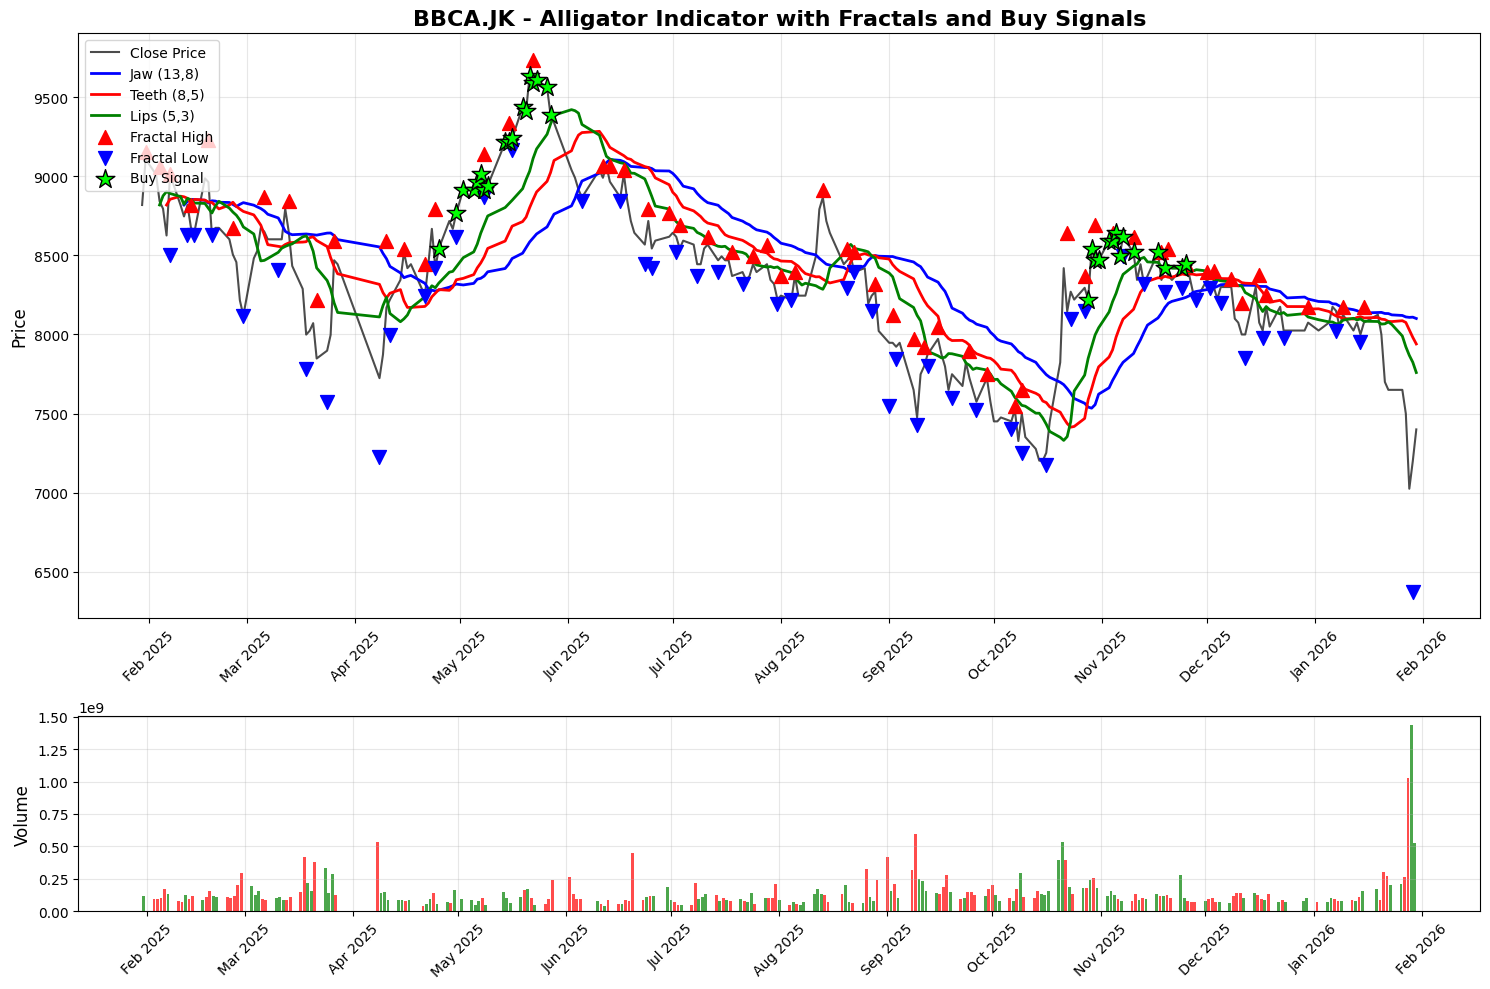


TRADING SIGNAL STATISTICS
Total trading days: 239
Number of buy signals: 32
Percentage of days with buy signals: 13.39%

Last buy signal on: 2025-11-25
Price at last signal: 8444.18
Current price: 7400.00

Average next-day return after buy signals: 0.25%
Max next-day gain: 3.93%
Max next-day loss: -2.04%

RECENT SIGNALS (Last 10 Trading Days)
             Close Alligator_Alignment  Signal
Date                                          
2026-01-19  8125.0             Bearish   False
2026-01-20  8000.0             Bearish   False
2026-01-21  7700.0             Bearish   False
2026-01-22  7650.0             Bearish   False
2026-01-23  7650.0             Bearish   False
2026-01-26  7650.0             Bearish   False
2026-01-27  7500.0             Bearish   False
2026-01-28  7025.0             Bearish   False
2026-01-29  7200.0             Bearish   False
2026-01-30  7400.0             Bearish   False


In [9]:
# 5. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot price and Alligator lines
ax1.plot(data.index, data['Close'], label='Close Price', color='black', linewidth=1.5, alpha=0.7)
ax1.plot(data.index, data['Jaw'], label='Jaw (13,8)', color='blue', linewidth=2)
ax1.plot(data.index, data['Teeth'], label='Teeth (8,5)', color='red', linewidth=2)
ax1.plot(data.index, data['Lips'], label='Lips (5,3)', color='green', linewidth=2)

# Highlight fractal points
fractal_high_points = data[data['Fractal_High']]
fractal_low_points = data[data['Fractal_Low']]
ax1.scatter(fractal_high_points.index, fractal_high_points['High'],
           color='red', marker='^', s=100, label='Fractal High', zorder=5)
ax1.scatter(fractal_low_points.index, fractal_low_points['Low'],
           color='blue', marker='v', s=100, label='Fractal Low', zorder=5)

# Mark buy signals
buy_signals = data[data['Signal']]
ax1.scatter(buy_signals.index, buy_signals['Close'],
           color='lime', marker='*', s=200, label='Buy Signal', zorder=6, edgecolors='black')

# Add shaded background for signals
for idx in buy_signals.index:
    ax1.axvspan(idx, idx, alpha=0.3, color='lime', ymin=0, ymax=1, linewidth=0)

ax1.set_title('BBCA.JK - Alligator Indicator with Fractals and Buy Signals', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Add volume subplot
colors = ['red' if data['Close'].iloc[i] < data['Close'].iloc[i-1] else 'green'
          for i in range(1, len(data))]
ax2.bar(data.index[1:], data['Volume'].iloc[1:], color=colors, alpha=0.7)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

# Format x-axis
for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# 6. Additional statistics
print("\n" + "="*60)
print("TRADING SIGNAL STATISTICS")
print("="*60)
print(f"Total trading days: {len(data)}")
print(f"Number of buy signals: {data['Signal'].sum()}")
print(f"Percentage of days with buy signals: {data['Signal'].sum()/len(data)*100:.2f}%")

if len(buy_signals) > 0:
    print(f"\nLast buy signal on: {buy_signals.index[-1].strftime('%Y-%m-%d')}")
    print(f"Price at last signal: {buy_signals['Close'].iloc[-1]:.2f}")
    print(f"Current price: {data['Close'].iloc[-1]:.2f}")

    if len(buy_signals) > 1:
        # Calculate performance after buy signals
        returns = []
        for idx in buy_signals.index[:-1]:  # Exclude last signal for forward looking
            next_day_idx = data.index.get_loc(idx) + 1
            if next_day_idx < len(data):
                returns.append((data['Close'].iloc[next_day_idx] / buy_signals.loc[idx, 'Close'] - 1) * 100)

        if returns:
            print(f"\nAverage next-day return after buy signals: {np.mean(returns):.2f}%")
            print(f"Max next-day gain: {max(returns):.2f}%")
            print(f"Max next-day loss: {min(returns):.2f}%")

# 7. Optional: Create a simplified signal table
print("\n" + "="*60)
print("RECENT SIGNALS (Last 10 Trading Days)")
print("="*60)
recent_data = data.tail(10)[['Close', 'Jaw', 'Teeth', 'Lips', 'Signal']].copy()
recent_data['Alligator_Alignment'] = recent_data.apply(
    lambda x: 'Bullish' if x['Lips'] > x['Teeth'] > x['Jaw'] else 'Bearish', axis=1
)
print(recent_data[['Close', 'Alligator_Alignment', 'Signal']])